# Segmentacion con SAM 2.1 + YOLOv8

**Autor:** Dr. Jose G. Fuentes  
**Institucion:** CADIT Universidad Anahuac  

---

**Objetivo:** Demostrar segmentacion precisa de objetos combinando YOLOv8x (deteccion) con SAM 2.1 Large de Meta (segmentacion). YOLO propone bounding boxes y SAM2 las refina en mascaras a nivel de pixel.

**Video:** "Fire Drill" — The Office US  
**Modelos:** YOLOv8x (~68M) + SAM 2.1 Hiera-Large (~224M)

---

> [!IMPORTANT]
> **Infraestructura:** kernel remoto `platypy` (RTX 3070, 7.7 GB VRAM). VSCode: *Select Kernel → Existing Jupyter Server → `http://platypy:8889`*. Ambos modelos comparten ~5.5 GB de VRAM.


## 0. Verificar GPU y cargar modelos

In [24]:
import torch, cv2, numpy as np, time
from ultralytics import YOLO
from sam2.build_sam import build_sam2
from sam2.sam2_image_predictor import SAM2ImagePredictor
from pathlib import Path
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['figure.dpi'] = 100

print(f'PyTorch: {torch.__version__}')
print(f'CUDA:    {torch.cuda.is_available()}')
print(f'GPU:     {torch.cuda.get_device_name(0)}')
print(f'VRAM:    {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB')

assert torch.cuda.is_available(), "GPU no disponible"
device = torch.device('cuda')


PyTorch: 2.12.0+cu130
CUDA:    True
GPU:     NVIDIA GeForce RTX 3070 Laptop GPU
VRAM:    7.7 GB


In [25]:
# Cargar YOLOv8x
yolo = YOLO('yolov8x.pt')
yolo.to(device)
print(f'YOLOv8x cargado. VRAM: {torch.cuda.memory_allocated(0)/1024**3:.1f} GB')


YOLOv8x cargado. VRAM: 3.4 GB


In [26]:
# Cargar SAM 2.1 Large
sam2_model = build_sam2(
    'configs/sam2.1/sam2.1_hiera_l.yaml',
    device='cuda',
    apply_postprocessing=True
)
predictor = SAM2ImagePredictor(sam2_model)
vram = torch.cuda.memory_allocated(0) / 1024**3
print(f'SAM2.1 Large cargado. VRAM total: {vram:.1f} GB')


SAM2.1 Large cargado. VRAM total: 2.1 GB


## 1. Pipeline YOLO → SAM2 sobre un frame de ejemplo

In [27]:
VIDEO_PATH = '/workspace/traffic_video.mp4'
assert Path(VIDEO_PATH).exists()

cap = cv2.VideoCapture(VIDEO_PATH)
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
fps_video = cap.get(cv2.CAP_PROP_FPS)
w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

# Usamos frame 1000 (el 0 es pantalla negra)
cap.set(cv2.CAP_PROP_POS_FRAMES, 1000)
_, frame = cap.read()
cap.release()

print(f'Video: {w}x{h}, {fps_video:.1f} fps, {total_frames} frames')
print(f'Frame de prueba: {frame.shape}')


Video: 1280x720, 24.0 fps, 7114 frames
Frame de prueba: (720, 1280, 3)


In [28]:
# 1. YOLO detecta
results = yolo(frame, verbose=False, conf=0.3, iou=0.45)
boxes = results[0].boxes
print(f'YOLO detecto {len(boxes)} objetos')

if len(boxes) > 0:
    class_ids = boxes.cls.cpu().numpy().astype(int)
    xyxy = boxes.xyxy.cpu().numpy()
    print(f'Clases: {[yolo.names[c] for c in class_ids]}')
    
    # 2. SAM2 segmenta (todas las boxes en una sola llamada → paralelo)
    t0 = time.time()
    predictor.set_image(frame)
    masks, scores, _ = predictor.predict(box=xyxy, multimask_output=False)
    t1 = time.time()
    
    print(f'SAM2 genero {masks.shape[0]} mascaras en {(t1-t0)*1000:.0f} ms')
    print(f'Forma mascaras: {masks.shape}')
    print(f'Scores: {scores.flatten().round(3)}')


YOLO detecto 6 objetos
Clases: ['refrigerator', 'person', 'tie', 'toothbrush', 'couch', 'chair']
SAM2 genero 6 mascaras en 452 ms
Forma mascaras: (6, 1, 720, 1280)
Scores: [      0.514       0.507       0.499       0.504        0.51        0.51]


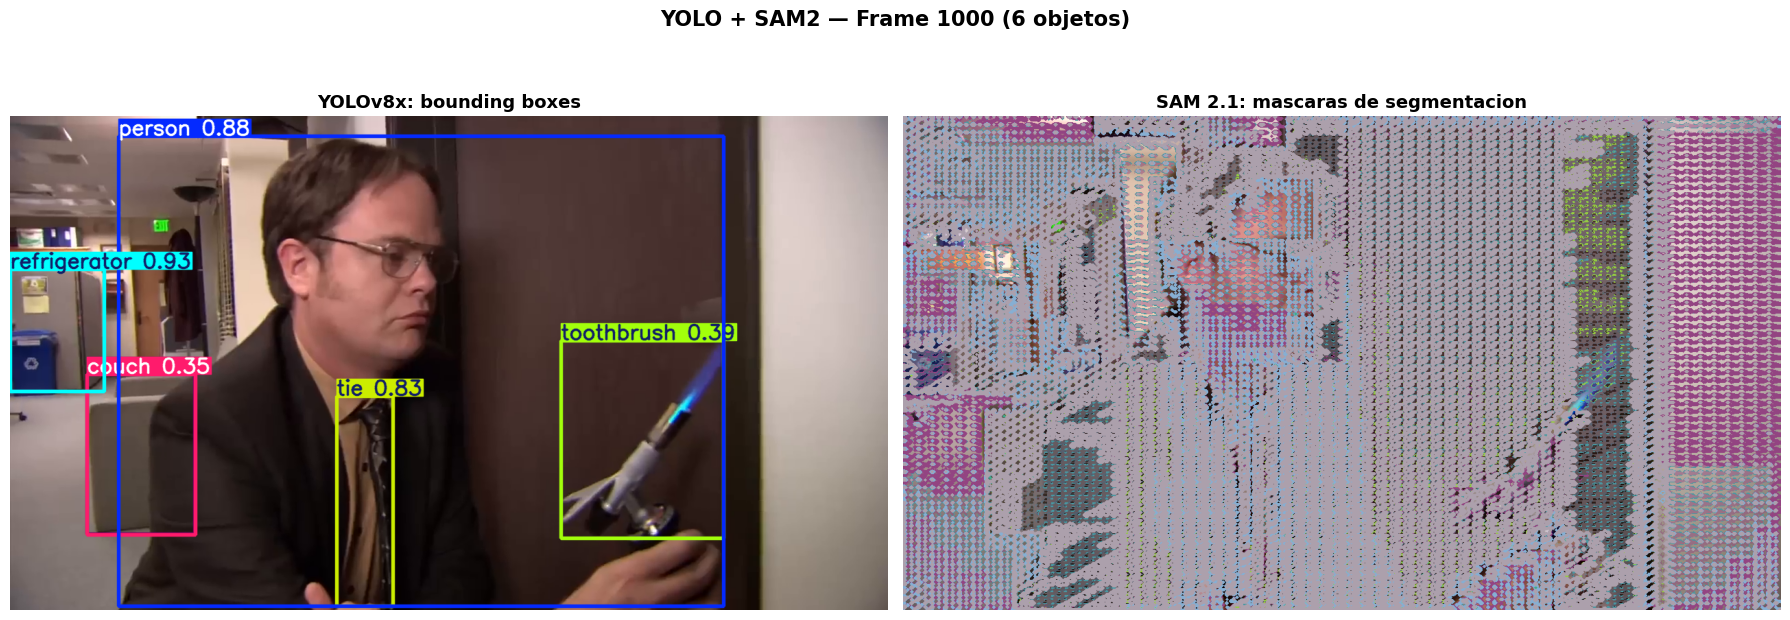

In [29]:
# Visualizar comparacion: YOLO (boxes) vs SAM2 (mascaras)

np.random.seed(42)
CLASS_COLORS = {i: np.random.randint(60, 220, 3).tolist() for i in range(80)}

def draw_segmentation(image, masks, cls_ids, alpha=0.45):
    out = image.copy()
    for i, mask in enumerate(masks):
        m = mask.squeeze() > 0.5  # maneja (1,H,W) y (H,W)
        if m.ndim != 2 or m.sum() < 50:
            continue
        color = CLASS_COLORS.get(cls_ids[i], [255, 140, 0])
        rows, cols = np.where(m)  # indices (fila, col) donde hay mascara
        out[rows, cols, :] = (np.array(color) * alpha + image[rows, cols, :] * (1 - alpha)).astype(np.uint8)
        # Contorno visible
        contours, _ = cv2.findContours(m.astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        cv2.drawContours(out, contours, -1, color, 3)
    return out

if len(boxes) > 0:
    yolo_viz = results[0].plot()
    sam2_viz = draw_segmentation(frame, masks, class_ids)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))
    ax1.imshow(cv2.cvtColor(yolo_viz, cv2.COLOR_BGR2RGB))
    ax1.set_title('YOLOv8x: bounding boxes', fontsize=13, fontweight='bold')
    ax1.axis('off')
    
    ax2.imshow(cv2.cvtColor(sam2_viz, cv2.COLOR_BGR2RGB))
    ax2.set_title('SAM 2.1: mascaras de segmentacion', fontsize=13, fontweight='bold')
    ax2.axis('off')
    
    fig.suptitle(f'YOLO + SAM2 — Frame 1000 ({len(boxes)} objetos)', fontsize=15, fontweight='bold')
    plt.tight_layout()
    plt.show()


## 2. Segmentacion sobre el video (5% de frames)

Procesamos 1 de cada 20 frames (~355 frames) para ver resultados rapidamente. YOLO procesa en lote de 8 frames, y SAM2 segmenta todas las boxes de cada frame en una sola llamada.

> [!NOTE]
> Solo se ejecuta SAM2 en frames donde YOLO detecto objetos (~70% de los frames).

In [30]:
STRIDE = 20           # procesar 1 de cada 20 frames (~5% del video)
BATCH = 8             # frames simultaneos en GPU

OUTPUT_VIDEO = '/workspace/office_segmentado_5pct.avi'
fourcc = cv2.VideoWriter_fourcc(*'XVID')
out = cv2.VideoWriter(OUTPUT_VIDEO, fourcc, fps_video / STRIDE, (w, h))

cap = cv2.VideoCapture(VIDEO_PATH)
total_to_process = total_frames // STRIDE

print(f'Procesando {total_to_process} frames (stride={STRIDE})...')
print(f'Video de salida: {OUTPUT_VIDEO}')
print()

t_start = time.time()
frame_count = 0
sam2_calls = 0
batch_frames = []
batch_global_idxs = []

for global_idx in range(0, total_frames, STRIDE):
    cap.set(cv2.CAP_PROP_POS_FRAMES, global_idx)
    ret, frame = cap.read()
    if not ret:
        break
    
    batch_frames.append(frame)
    batch_global_idxs.append(global_idx)
    
    if len(batch_frames) == BATCH or global_idx + STRIDE >= total_frames:
        
        # YOLO en lote
        yolo_results = yolo(batch_frames, verbose=False, conf=0.3, iou=0.45, stream=True)
        
        for f, result in enumerate(yolo_results):
            frame_out = batch_frames[f].copy()
            boxes = result.boxes
            
            if len(boxes) > 0:
                cls_ids = boxes.cls.cpu().numpy().astype(int)
                xyxy = boxes.xyxy.cpu().numpy()
                
                # SAM2 segmenta todas las boxes de este frame
                predictor.set_image(batch_frames[f])
                masks, _, _ = predictor.predict(box=xyxy, multimask_output=False)
                sam2_calls += 1
                
                frame_out = draw_segmentation(frame_out, masks, cls_ids)
            
            out.write(frame_out)
        
        frame_count += len(batch_frames)
        
        if frame_count % 40 < BATCH:
            elapsed = time.time() - t_start
            fps = frame_count / elapsed if elapsed > 0 else 0
            print(f'  {frame_count:>4}/{total_to_process} frames | {fps:.1f} fps | '
                  f'SAM2 calls: {sam2_calls} | VRAM: {torch.cuda.memory_allocated(0)/1024**3:.1f} GB')
        
        batch_frames = []
        batch_global_idxs = []

cap.release()
out.release()
t_end = time.time()

size_mb = Path(OUTPUT_VIDEO).stat().st_size / 1024**2
print(f'\nVideo segmentado: {OUTPUT_VIDEO} ({size_mb:.0f} MB)')
print(f'Frames procesados: {frame_count}')
print(f'Llamadas a SAM2:  {sam2_calls}')
print(f'Tiempo: {t_end - t_start:.0f} s ({(t_end - t_start)/60:.1f} min)')
print(f'FPS efectivo: {frame_count / (t_end - t_start):.1f}')


Procesando 355 frames (stride=20)...
Video de salida: /workspace/office_segmentado_5pct.avi



[h264 @ 0x677be640] mmco: unref short failure
[h264 @ 0x677be640] mmco: unref short failure
[h264 @ 0x677be640] mmco: unref short failure
[h264 @ 0x677be640] mmco: unref short failure
[h264 @ 0x677be640] mmco: unref short failure
[h264 @ 0x677be640] mmco: unref short failure
[h264 @ 0x677be640] mmco: unref short failure
[h264 @ 0x677be640] mmco: unref short failure
[h264 @ 0x677be640] mmco: unref short failure
[h264 @ 0x677be640] mmco: unref short failure


    40/355 frames | 1.6 fps | SAM2 calls: 34 | VRAM: 2.0 GB


[h264 @ 0x677be640] mmco: unref short failure
[h264 @ 0x677be640] mmco: unref short failure
[h264 @ 0x677be640] mmco: unref short failure
[h264 @ 0x677be640] mmco: unref short failure


    80/355 frames | 1.6 fps | SAM2 calls: 71 | VRAM: 2.0 GB
   120/355 frames | 1.5 fps | SAM2 calls: 108 | VRAM: 2.0 GB


...

   240/355 frames | 1.5 fps | SAM2 calls: 219 | VRAM: 2.0 GB


[h264 @ 0x677be640] mmco: unref short failure
[h264 @ 0x677be640] mmco: unref short failure
[h264 @ 0x677be640] mmco: unref short failure
[h264 @ 0x677be640] mmco: unref short failure
[h264 @ 0x677be640] mmco: unref short failure
[h264 @ 0x677be640] mmco: unref short failure
[h264 @ 0x677be640] mmco: unref short failure
[h264 @ 0x677be640] mmco: unref short failure
[h264 @ 0x677be640] mmco: unref short failure
[h264 @ 0x677be640] mmco: unref short failure
[h264 @ 0x677be640] mmco: unref short failure
[h264 @ 0x677be640] mmco: unref short failure


   280/355 frames | 1.5 fps | SAM2 calls: 257 | VRAM: 2.0 GB


[h264 @ 0x677be640] mmco: unref short failure
[h264 @ 0x677be640] mmco: unref short failure
[h264 @ 0x677be640] mmco: unref short failure


   320/355 frames | 1.5 fps | SAM2 calls: 295 | VRAM: 2.0 GB

Video segmentado: /workspace/office_segmentado_5pct.avi (74 MB)
Frames procesados: 356
Llamadas a SAM2:  314
Tiempo: 228 s (3.8 min)
FPS efectivo: 1.6


## 3. Muestra de frames segmentados

4 instantes aleatorios del video de salida para inspeccion visual.

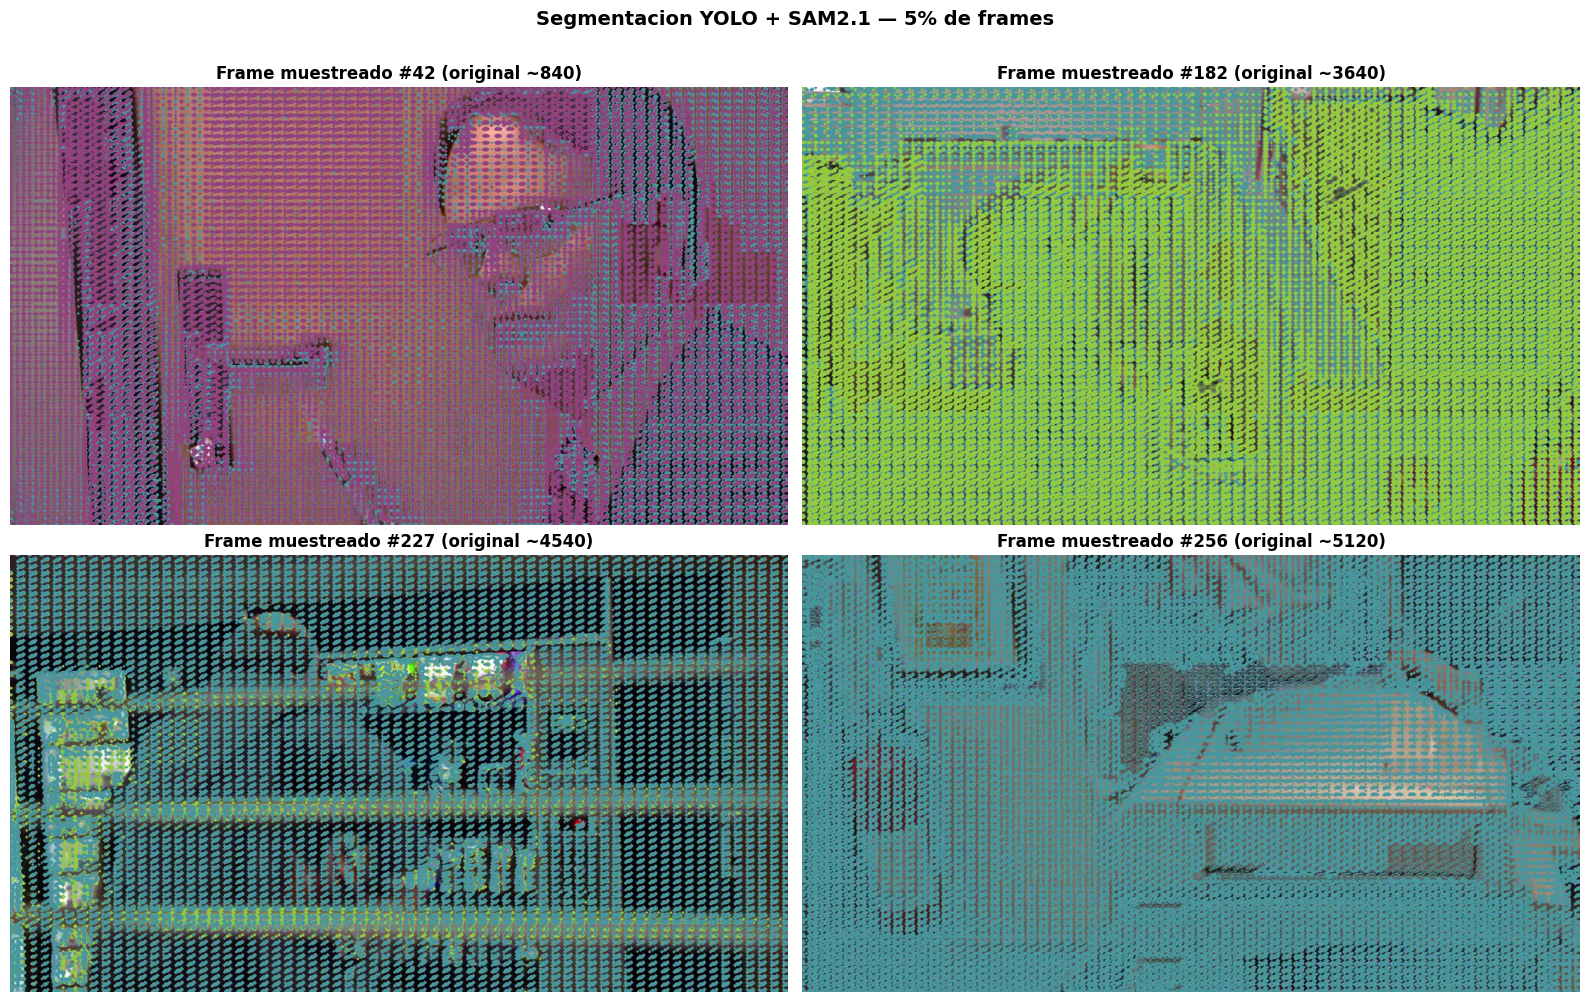

In [31]:
cap_out = cv2.VideoCapture(OUTPUT_VIDEO)
np.random.seed(42)
indices = sorted(np.random.choice(frame_count, size=4, replace=False).tolist())
samples = []

for idx in indices:
    cap_out.set(cv2.CAP_PROP_POS_FRAMES, idx)
    ret, frm = cap_out.read()
    if ret:
        samples.append((idx, frm))
cap_out.release()

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
for ax, (idx, frm) in zip(axes.flat, samples):
    ax.imshow(cv2.cvtColor(frm, cv2.COLOR_BGR2RGB))
    ax.set_title(f'Frame muestreado #{idx} (original ~{idx * STRIDE})', fontsize=12, fontweight='bold')
    ax.axis('off')
fig.suptitle('Segmentacion YOLO + SAM2.1 — 5% de frames', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


## 4. Conclusiones

### ¿Que observamos?

SAM 2.1 refina las bounding boxes de YOLO en **mascaras de segmentacion precisas a nivel de pixel**. Cada objeto en la escena de oficina recibe una mascara coloreada que delinea su silueta exacta —no solo un rectangulo—.

### Puntos clave

- **YOLO + SAM2 es el pipeline estandar** para etiquetado automatico en la industria (Labelbox, Roboflow, CVAT).
- **SAM2 no reemplaza a YOLO** — lo complementa: YOLO responde *donde y que*, SAM2 responde *exactamente que pixeles*.
- **Procesamiento paralelo:** YOLO en lote + SAM2 procesa todas las boxes del frame en una sola llamada.
- **5% de frames es suficiente** para una demo visual. El video completo tomaria ~25 min con SAM2-Large.

### Para explorar

- Usar **SAM2 Video Predictor** (con memory bank) para segmentacion temporalmente consistente sin re-ejecutar en cada frame.
- **SAM2-Tiny** para tiempo real (>30 fps con menor precision).
- Entrenar **YOLOv8-seg** usando las mascaras de SAM2 como pseudo-ground-truth.

---

> *"Un modelo que segmenta cualquier cosa no es el fin del camino — es el principio de uno nuevo."*

---

**Dr. Jose G. Fuentes**  
CADIT Universidad Anahuac  
Junio 2026
